# Interpreting Financial NLP Models with SHAP

**Chapter 12: Advanced Models for Tabular Data**
**Section 12.5: Model Explainability with SHAP**

## Purpose

This notebook extends SHAP from tabular models to a pretrained financial language model. It
examines whether token attributions support FinBERT's sentiment decisions and shows how a token's
contribution can change with context.

## Learning objectives

After completing this notebook, you will be able to:

- explain Transformer sentiment probabilities with token-level SHAP values;
- distinguish a token's contribution to one prediction from its standalone sentiment;
- test a contextual explanation with a controlled text perturbation; and
- state what attribution can, and cannot, establish in model validation.

**Prerequisites**: Sections 12.5 on SHAP and Chapter 10 on financial text features. The notebook
downloads the pinned FinBERT-tone checkpoint on first use. A CUDA-capable PyTorch environment is
faster, but the same inference path runs on CPU.

In [1]:
"""Apply SHAP to FinBERT for token-level financial sentiment attribution."""

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

import torch  # isort:skip  # Import before SHAP to initialize the CUDA runtime first.
import shap
from transformers import AutoModelForSequenceClassification, AutoTokenizer

from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, add_message_title, zero_line

In [2]:
MAX_SENTENCES = 0  # 0 uses the full teaching sample
SEED = 42

In [3]:
set_global_seeds(SEED)

MODEL_NAME = "yiyanghkust/finbert-tone"
MODEL_REVISION = "4921590d3c0c3832c0efea24c8381ce0bda7844b"
LABEL_ORDER = ("Negative", "Neutral", "Positive")
TORCH_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Inference device: {'CUDA GPU' if TORCH_DEVICE.type == 'cuda' else 'CPU'}")
print(f"FinBERT revision: {MODEL_REVISION[:12]}")

Inference device: CUDA GPU
FinBERT revision: 4921590d3c0c


## Load a pinned FinBERT checkpoint

FinBERT-tone is already fine-tuned for three-way financial sentiment. Pinning the model revision
makes the weights and tokenizer part of the notebook's reproducibility contract. The checkpoint's
native class indices are validated, then outputs are reordered once into the reader-facing order
Negative, Neutral, Positive.

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, revision=MODEL_REVISION)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    revision=MODEL_REVISION,
).to(TORCH_DEVICE)
model.eval()

model_labels = tuple(model.config.id2label[index] for index in range(model.config.num_labels))
if set(model_labels) != set(LABEL_ORDER):
    raise ValueError(f"Unexpected FinBERT labels: {model_labels}")

The probability wrapper is the single class-order boundary between FinBERT and SHAP. It batches
inference, applies softmax to the native logits, and reorders columns by the checkpoint's label
metadata rather than assuming that model indices have a particular meaning.

In [5]:
def predict_proba(texts):
    """Return FinBERT probabilities in LABEL_ORDER for SHAP."""
    text_batch = [str(text) for text in texts]
    encoded = tokenizer(text_batch, padding=True, return_tensors="pt").to(TORCH_DEVICE)
    with torch.inference_mode():
        native_probabilities = torch.softmax(model(**encoded).logits, dim=-1).cpu().numpy()
    display_indices = [model_labels.index(label) for label in LABEL_ORDER]
    return native_probabilities[:, display_indices]

Five short sentences establish the model's behavior before attribution. These are constructed
teaching examples, not a labeled evaluation sample, so confidence describes model certainty on
each example rather than out-of-sample accuracy.

In [6]:
test_sentences = [
    "Revenue growth exceeded analyst expectations.",
    "The company announced significant layoffs.",
    "Net loss narrowed from the prior year.",
    "Guidance was raised for the fiscal year.",
    "Management expressed concerns about margin pressure.",
]

test_probabilities = predict_proba(test_sentences)
winner_indices = test_probabilities.argmax(axis=1)

prediction_summary = pl.DataFrame(
    {
        "text": test_sentences,
        "prediction": [LABEL_ORDER[index] for index in winner_indices],
        "confidence": test_probabilities.max(axis=1),
    }
)
prediction_summary

text,prediction,confidence
str,str,f32
"""Revenue growth exceeded analys…","""Positive""",1.0
"""The company announced signific…","""Negative""",0.581351
"""Net loss narrowed from the pri…","""Positive""",0.747484
"""Guidance was raised for the fi…","""Positive""",0.999997
"""Management expressed concerns …","""Negative""",1.0


## Explain individual predictions

The text masker creates coalitions by hiding token groups and querying the probability wrapper.
Because the explained outputs are probabilities, each SHAP value is a contribution in probability
points relative to the explainer's baseline. A positive value pushes toward the named class; a
negative value pushes away from it.

In [7]:
explainer = shap.Explainer(
    predict_proba,
    tokenizer,
    output_names=list(LABEL_ORDER),
    algorithm="partition",
)

explain_sentences = [
    "Net loss narrowed significantly from the prior year.",
    "Revenue growth slowed amid weakening demand.",
    "The company raised its full-year guidance.",
]

explain_probabilities = predict_proba(explain_sentences)
explain_winners = explain_probabilities.argmax(axis=1)
shap_values = explainer(explain_sentences)

Each panel ranks tokens by absolute contribution to that sentence's predicted class. Direction is
relative to the predicted class: green pushes its probability higher and red pushes it lower.

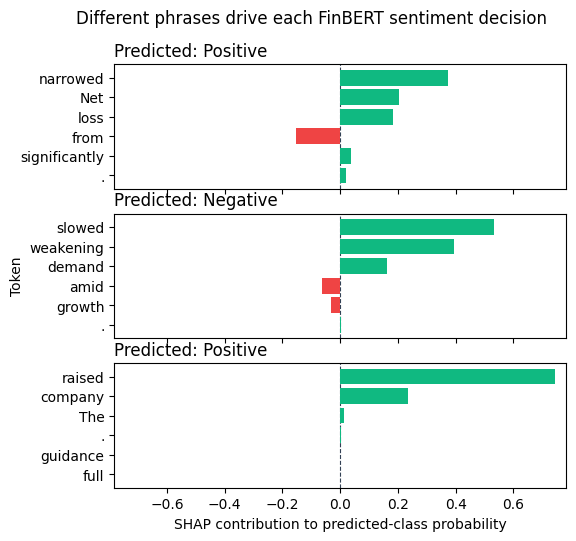

In [8]:
fig, axes = plt.subplots(3, 1, figsize=FIGSIZE["grid_3x2"], sharex=True)

panel_rows = []
max_abs_contribution = 0.0
for sentence_index, (sentence, class_index) in enumerate(
    zip(explain_sentences, explain_winners, strict=True)
):
    tokens = shap_values[sentence_index].data
    values = shap_values[sentence_index, :, class_index].values
    contributions = [
        (str(token).strip(), float(value))
        for token, value in zip(tokens, values, strict=True)
        if str(token).strip() and str(token).strip() not in {"[CLS]", "[SEP]", "[PAD]"}
    ]
    strongest = sorted(contributions, key=lambda item: abs(item[1]), reverse=True)[:6]
    max_abs_contribution = max(max_abs_contribution, *(abs(value) for _, value in strongest))
    predicted = LABEL_ORDER[class_index]
    panel_rows.append((sentence, predicted, strongest))

for ax, (_, predicted, strongest) in zip(axes, panel_rows, strict=True):
    tokens = [token for token, _ in strongest]
    contributions = [value for _, value in strongest]
    colors = [COLORS["positive"] if value >= 0 else COLORS["negative"] for value in contributions]

    ax.barh(tokens, contributions, color=colors)
    ax.invert_yaxis()
    ax.set_xlim(-1.05 * max_abs_contribution, 1.05 * max_abs_contribution)
    ax.set_title(f"Predicted: {predicted}", loc="left")
    zero_line(ax, axis="x")

axes[1].set_ylabel("Token")
axes[-1].set_xlabel("SHAP contribution to predicted-class probability")
fig.suptitle("Different phrases drive each FinBERT sentiment decision", x=0.06, ha="left")
plt.show()

## Controlled context test: narrowed versus widened

A token's SHAP value belongs to a complete input, not to the token in isolation. To test that
distinction, hold the sentence template fixed and replace only *narrowed* with *widened*. The
resulting predictions and Positive-class attributions provide an adversarial check on the
contextual interpretation. A sensible-looking local explanation does not guarantee that the model
will respond sensibly to a nearby input.

In [9]:
context_sentences = [
    "Net loss narrowed significantly from the prior year.",
    "Net loss widened significantly from the prior year.",
]
context_probabilities = predict_proba(context_sentences)
context_shap = explainer(context_sentences)
positive_index = LABEL_ORDER.index("Positive")

context_summary = pl.DataFrame(
    {
        "wording": ["narrowed", "widened"],
        "prediction": [LABEL_ORDER[index] for index in context_probabilities.argmax(axis=1)],
        "positive_probability": context_probabilities[:, positive_index],
    }
)
context_summary

wording,prediction,positive_probability
str,str,f32
"""narrowed""","""Positive""",0.696778
"""widened""","""Positive""",0.963374


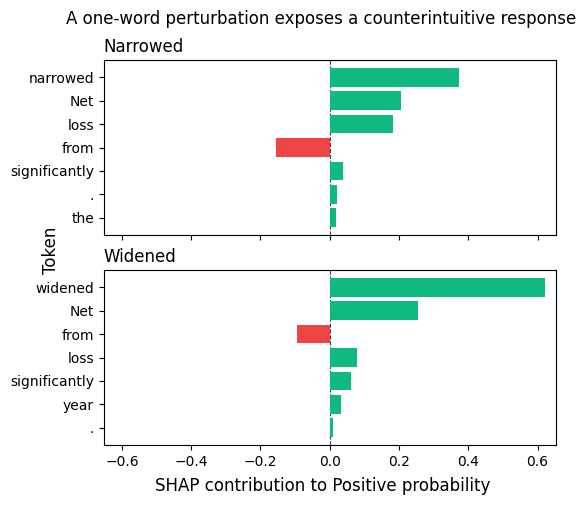

In [10]:
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE["dual_v"], sharex=True)

context_panels = []
context_limit = 0.0
for sentence_index, wording in enumerate(("narrowed", "widened")):
    tokens = context_shap[sentence_index].data
    values = context_shap[sentence_index, :, positive_index].values
    contributions = [
        (str(token).strip(), float(value))
        for token, value in zip(tokens, values, strict=True)
        if str(token).strip() and str(token).strip() not in {"[CLS]", "[SEP]", "[PAD]"}
    ]
    strongest = sorted(contributions, key=lambda item: abs(item[1]), reverse=True)[:7]
    context_limit = max(context_limit, *(abs(value) for _, value in strongest))
    context_panels.append((wording, strongest))

for ax, (wording, strongest) in zip(axes, context_panels, strict=True):
    tokens = [token for token, _ in strongest]
    contributions = [value for _, value in strongest]
    colors = [COLORS["positive"] if value >= 0 else COLORS["negative"] for value in contributions]

    ax.barh(tokens, contributions, color=colors)
    ax.invert_yaxis()
    ax.set_xlim(-1.05 * context_limit, 1.05 * context_limit)
    ax.set_title(wording.capitalize(), loc="left")
    zero_line(ax, axis="x")

fig.supylabel("Token")
fig.supxlabel("SHAP contribution to Positive probability")
fig.suptitle("A one-word perturbation exposes a counterintuitive response", x=0.06, ha="left")
plt.show()

## Aggregate a small teaching sample

Aggregating signed Positive-class contributions can reveal recurring patterns, but the ten
constructed sentences below are too small and too curated to support claims about a global finance
vocabulary. The chart is therefore a diagnostic of this teaching sample only. Repeated corpus
tokens contribute repeatedly to the sum.

In [11]:
teaching_sentences = [
    "Revenue exceeded expectations.",
    "Profit margins improved significantly.",
    "The company beat analyst estimates.",
    "Earnings per share increased.",
    "Growth accelerated in Q4.",
    "Sales declined sharply.",
    "Losses mounted during the quarter.",
    "Margins contracted due to costs.",
    "Revenue missed forecasts.",
    "Guidance was lowered.",
]
if MAX_SENTENCES > 0:
    teaching_sentences = teaching_sentences[:MAX_SENTENCES]

teaching_shap = explainer(teaching_sentences)

token_totals: dict[str, float] = {}
for sentence_index in range(len(teaching_sentences)):
    tokens = teaching_shap[sentence_index].data
    values = teaching_shap[sentence_index, :, positive_index].values
    for token, value in zip(tokens, values, strict=True):
        normalized = str(token).strip().lower()
        if not normalized or normalized in {"[cls]", "[sep]", "[pad]"}:
            continue
        token_totals[normalized] = token_totals.get(normalized, 0.0) + float(value)

top_positive = sorted(
    ((token, value) for token, value in token_totals.items() if value > 0),
    key=lambda item: item[1],
    reverse=True,
)[:6]
top_negative = sorted(
    ((token, value) for token, value in token_totals.items() if value < 0),
    key=lambda item: item[1],
)[:6]
ranked_tokens = sorted(
    ((token, value) for token, value in top_negative + top_positive if abs(value) >= 0.01),
    key=lambda item: item[1],
)

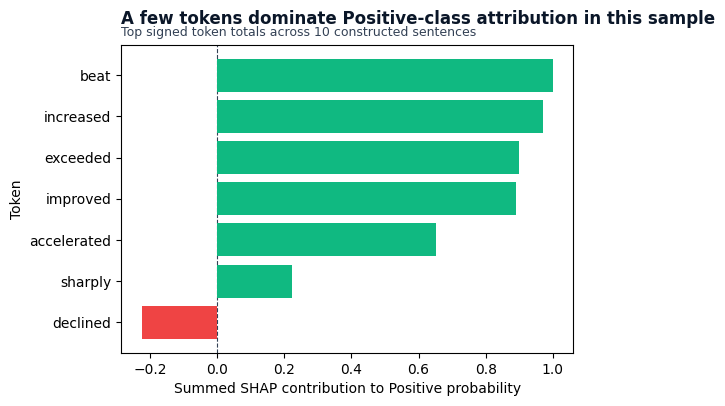

In [12]:
fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])

tokens = [token for token, _ in ranked_tokens]
contributions = [value for _, value in ranked_tokens]
colors = [COLORS["positive"] if value >= 0 else COLORS["negative"] for value in contributions]

ax.barh(tokens, contributions, color=colors)
zero_line(ax, axis="x")
ax.set_xlabel("Summed SHAP contribution to Positive probability")
ax.set_ylabel("Token")
add_message_title(
    ax,
    "A few tokens dominate Positive-class attribution in this sample",
    subtitle=f"Top signed token totals across {len(teaching_sentences)} constructed sentences",
)
plt.show()

## What attribution can support

- **Model validation**: token attributions can reveal reliance on implausible artifacts or language
  that deserves further testing. They cannot prove that training data were leak-free.
- **Debugging**: controlled text perturbations can identify brittle or counterintuitive decisions,
  but the explanation is still local to the model, masker, and input.
- **Research hypotheses**: recurring attributions in a representative corpus may motivate a
  candidate signal. They are predictive associations, not causal effects or evidence of alpha by
  themselves.

## Key takeaways

1. SHAP can decompose FinBERT class probabilities into token-level contributions using the same
   coalition logic applied to tabular features.
2. The narrowed-versus-widened perturbation shows why attribution needs an adversarial check: a
   locally plausible explanation can coexist with a counterintuitive nearby prediction.
3. Aggregated token scores depend on the sampled documents. This constructed sample demonstrates
   the workflow, not a stable finance-domain vocabulary.
4. Attribution is a diagnostic layer. Leakage checks, representative validation, and economic
   testing remain separate requirements before using text predictions in a strategy.

These examples complete the token-attribution extension in **Section 12.5**. Next,
`11_conformal_gbm` adds calibrated uncertainty intervals to gradient-boosting predictions.